# 08 — Method Comparison: Forest Plot

Side-by-side comparison of every method with effect estimates, CIs, and identifying assumptions.

The canonical numbers live in `report/portfolio_metrics.json`, written by `scripts/portfolio_analysis.py`. This notebook reads them so the table and forest plot can't drift from the report.

Key question: *Do all methods converge on the true effect (HR = 0.85 / −15% failure rate)?*
- **Yes →** robust finding.
- **No →** the diagnostic story (which assumption broke) becomes the headline.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys; sys.path.insert(0, '..')
from src.diagnostics import plot_hazard_ratio_forest

with open('../report/portfolio_metrics.json') as f:
    metrics = json.load(f)

print(f"Dataset: {metrics['dataset']['n_units']:,} units | true HR = {metrics['dataset']['true_hazard_ratio']}")

%matplotlib inline

Dataset: 5,000 units | true HR = 0.85


In [2]:
# Method-comparison table populated from portfolio_metrics.json
results = [
    {
        'method': 'Naive before/after (straw man)',
        'effect_estimate_pct': metrics['naive']['relative_pct'],
        'ci_lower': None,
        'ci_upper': None,
        'identifying_assumption': 'None \u2014 intentionally confounded',
    },
    {
        'method': 'Propensity Score Matching',
        'effect_estimate_pct': metrics['psm']['effect_pp'],
        'ci_lower': metrics['psm']['ci_lower_pp'],
        'ci_upper': metrics['psm']['ci_upper_pp'],
        'identifying_assumption': 'No unmeasured confounders',
    },
    {
        'method': 'Difference-in-Differences',
        'effect_estimate_pct': metrics['did']['effect_pp'],
        'ci_lower': metrics['did']['ci_lower_pp'],
        'ci_upper': metrics['did']['ci_upper_pp'],
        'identifying_assumption': 'Parallel pre-treatment trends',
    },
    {
        'method': 'Synthetic Control',
        'effect_estimate_pct': metrics['synthetic_control']['post_gap_pp'],
        'ci_lower': None,
        'ci_upper': None,
        'identifying_assumption': f"Pre-treatment fit (RMSPE = {metrics['synthetic_control']['pre_rmspe_pp']} pp \u2014 poor)",
    },
    {
        'method': 'Cox PH (Hazard Ratio)',
        'hazard_ratio': metrics['survival']['hazard_ratio'],
        'ci_lower': metrics['survival']['ci_lower'],
        'ci_upper': metrics['survival']['ci_upper'],
        'identifying_assumption': f"Proportional hazards (treatment PH p = {metrics['survival']['cox_treatment_ph_p_value']})",
    },
]
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

                        method  effect_estimate_pct  ci_lower  ci_upper                         identifying_assumption  hazard_ratio
Naive before/after (straw man)                 7.11       NaN       NaN                None — intentionally confounded           NaN
     Propensity Score Matching                -4.97    -7.520    -2.270                      No unmeasured confounders           NaN
     Difference-in-Differences                -3.70    -9.480     2.080                  Parallel pre-treatment trends           NaN
             Synthetic Control                10.50       NaN       NaN    Pre-treatment fit (RMSPE = 13.66 pp — poor)           NaN
         Cox PH (Hazard Ratio)                  NaN     0.718     0.918 Proportional hazards (treatment PH p = 0.1961)         0.812


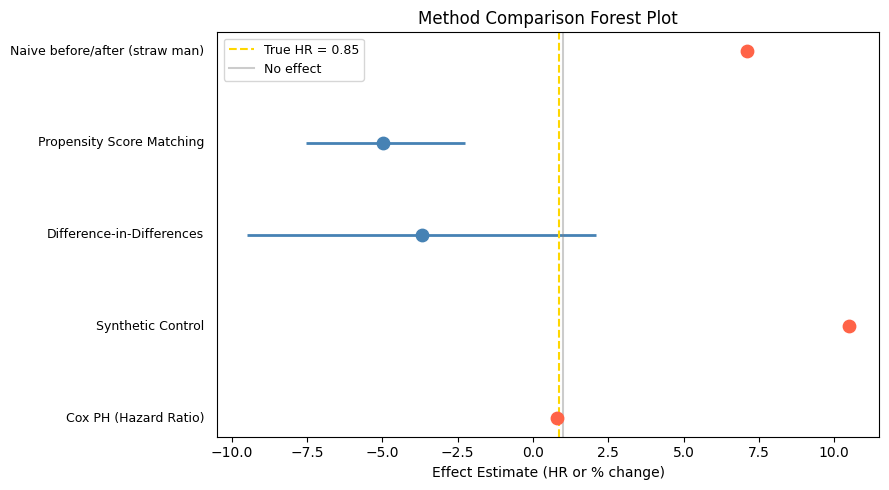

In [3]:
# Forest plot — reuse the shared diagnostic helper (canonical PNG is written by scripts/portfolio_analysis.py)
fig = plot_hazard_ratio_forest(results, true_hr=metrics['dataset']['true_hazard_ratio'])
plt.show()

In [4]:
# Headline table for the Quarto report
summary = pd.DataFrame({
    'Method': ['Naive', 'PSM', 'DiD', 'Synthetic Control', 'Cox PH'],
    'Identifying Assumption': [
        'None (intentionally wrong)',
        'No unmeasured confounders (strong)',
        'Parallel pre-treatment trends (testable)',
        'Pre-treatment trajectory fit (visual)',
        'Proportional hazards (Schoenfeld test)',
    ],
    'What It Recovers': ['Confounded rate', 'ATT', 'ATT for timed rollout', 'Counterfactual gap', 'Hazard ratio + B10-life'],
    'Effect Estimate': [
        f"+{metrics['naive']['relative_pct']}% relative (wrong direction)",
        f"{metrics['psm']['effect_pp']} pp [{metrics['psm']['ci_lower_pp']}, {metrics['psm']['ci_upper_pp']}]",
        f"{metrics['did']['effect_pp']} pp [{metrics['did']['ci_lower_pp']}, {metrics['did']['ci_upper_pp']}]",
        f"+{metrics['synthetic_control']['post_gap_pp']} pp (rejected \u2014 poor pre-fit)",
        f"HR = {metrics['survival']['hazard_ratio']} [{metrics['survival']['ci_lower']}, {metrics['survival']['ci_upper']}]",
    ],
})
print(summary.to_string(index=False))
print(f"\nTrue HR = {metrics['dataset']['true_hazard_ratio']} | Cox HR = {metrics['survival']['hazard_ratio']} (within CI; recovers the truth).")
print(f"B10-life: Variant A = {metrics['survival']['b10_a_months']} months \u2192 Variant B = {metrics['survival']['b10_b_months']} months (+{metrics['survival']['b10_delta_months']} months warranty window).")

           Method                   Identifying Assumption        What It Recovers                    Effect Estimate
            Naive               None (intentionally wrong)         Confounded rate  +7.11% relative (wrong direction)
              PSM       No unmeasured confounders (strong)                     ATT            -4.97 pp [-7.52, -2.27]
              DiD Parallel pre-treatment trends (testable)   ATT for timed rollout              -3.7 pp [-9.48, 2.08]
Synthetic Control    Pre-treatment trajectory fit (visual)      Counterfactual gap +10.5 pp (rejected — poor pre-fit)
           Cox PH   Proportional hazards (Schoenfeld test) Hazard ratio + B10-life          HR = 0.812 [0.718, 0.918]

True HR = 0.85 | Cox HR = 0.812 (within CI; recovers the truth).
B10-life: Variant A = 6.0 months → Variant B = 8.0 months (+2.0 months warranty window).
